In [16]:
import pandas as pd

df = pd.read_csv("D:/Goutham/Projects/Python/Project 2/Project  -  Simple Linear Regression/2. Simple Linear Regression/delivery_time.csv")
df.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [17]:
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes


Index(['Delivery Time', 'Sorting Time'], dtype='object')

In [18]:
df.columns = df.columns.str.replace(" ", "_")
df.head()

,Delivery_Time,Sorting_Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


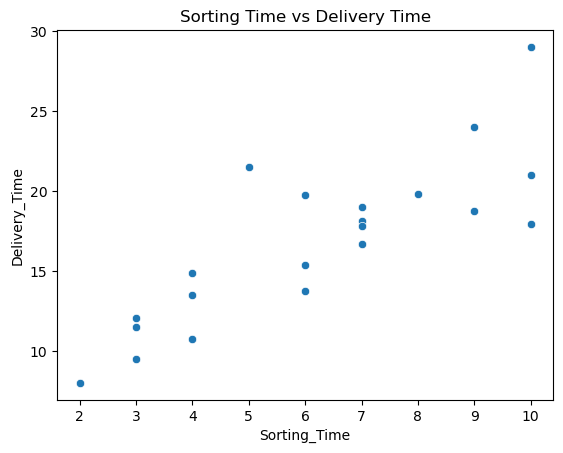

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Sorting_Time', y='Delivery_Time', data=df)
plt.title("Sorting Time vs Delivery Time")
plt.show()

In [20]:
df.corr()

,Delivery_Time,Sorting_Time
Delivery_Time,1.000000,0.825997
Sorting_Time,0.825997,1.000000


In [21]:
from sklearn.linear_model import LinearRegression

X = df[['Sorting_Time']]
y = df['Delivery_Time']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [22]:
model.coef_
model.intercept_

np.float64(6.58273397199706)

In [23]:
y_pred = model.predict(X)

In [24]:
from sklearn.metrics import r2_score

r2_score(y, y_pred)

0.6822714748417231

In [32]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# LOG MODEL
X_log = np.log(df[['Sorting_Time']])

model_log = LinearRegression()
model_log.fit(X_log, y)

y_pred_log = model_log.predict(X_log)

r2_log = r2_score(y, y_pred_log)

print("Log Model R2:", r2_log)

Log Model R2: 0.6954434611324223


In [33]:
# EXP MODEL (log y)
y_log = np.log(y)

model_exp = LinearRegression()
model_exp.fit(X, y_log)

y_pred_exp = np.exp(model_exp.predict(X))

r2_exp = r2_score(y, y_pred_exp)

print("Exponential Model R2:", r2_exp)

Exponential Model R2: 0.6475457259313306


In [34]:
model_log

LinearRegression()

In [35]:
new_data = pd.DataFrame({'Sorting_Time': [5, 10, 15]})

predictions = model_log.predict(np.log(new_data))

predictions

array([15.71449599, 21.98291253, 25.64970115])

In [37]:
output = pd.DataFrame({
    'Sorting_Time': [5, 10, 15],
    'Predicted_Delivery_Time': predictions
})

output.to_csv("D:/Goutham/Projects/Python/Project 2/Project  -  Simple Linear Regression/2. Simple Linear Regression/delivery_predictions.csv", index=False)

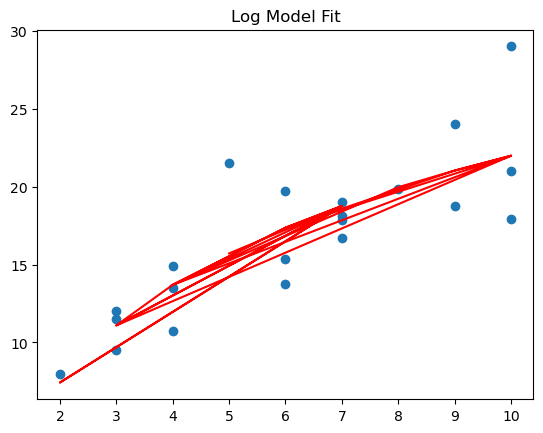

In [38]:
plt.scatter(df['Sorting_Time'], df['Delivery_Time'])
plt.plot(df['Sorting_Time'], y_pred_log, color='red')
plt.title("Log Model Fit")
plt.show()